## Download dataset

In [1]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
api = KaggleApi()
api.authenticate()

if not os.path.exists("../datasets/Students Social Media Addiction.csv"):
    api.dataset_download_files(
        "zahranusratt/student-social-media-addiction-analysis-dataset",
        path="../datasets",
        unzip=True
    )
else:
    print("dataset already on local files")

csv_file = os.path.join("../datasets","Students Social Media Addiction.csv")
df = pd.read_csv(csv_file)

print("dataset ready to use")

dataset already on local files
dataset ready to use


## General dataset exploration

In [2]:
print('*'*30)
print('GENERAL DATASET INFORMATION')
print('*'*30)

print('Columns and records count:')
df.info()
df.describe()
print('*'*30)

print('Gender distribution:')
print(df['Gender'].value_counts())
print('*'*30)

print('Age calculations:')
print(f"mean:\t {df['Age'].mean():.1f}")
print('median:\t', df['Age'].median())
print('*'*30)

print('Countries data:')
print('unique count:\t', df['Country'].nunique()) # len(df['Country'].unique())

******************************
GENERAL DATASET INFORMATION
******************************
Columns and records count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Confli

## Methodology

This section provides a brief explanation of the techniques used in this EDA, along with how questions have been raised and how the graphs are plotted to provide insights to answer them.
The analysis generally follows this structure: **Introduction-like approach > Questioning > Plot > Interpretation.**.

### Univariate analysis
Graphs are plotted based using **one feature at a time**, in order to understand its distribution over the dataset. Histograms and boxplots are used to visualize characteristics such as central tendency, dispersion, outliers, noise and errors in the dataset.
Understanding the distribution of features is important because it can determine if the data approximates a normal distribution. Additionally, identifying distribution patterns provides useful context for later correlation analysis.

### Bivariate analysis
Graphs are plotted based on **two features at a time**, to determining empirical relationships between them. Scatterplots, correlation matrices and distribution over X and Y axis. Understanding these relationships can identify features that are more likely to drive others.

### Multivariate analysis
Graphs are plotted based on **more than two features at a time**, this is used to uncover deeper insights and feature interactions that are not visible under simpler data analysis. Which is key for building more accurate ML models later on.

### Key insights and final considerations
The results are sintetized together in a concise manner, providing details of what can be considerate reliable or not in the sample. Additionally what are the next steps before using this data to create a regression/classification model. 

---

## Univariate analysis
This section investigates the distribution of individual variables within the dataset.
The following features were selected for analysis:
- Avg_Daily_Usage_Hours
- Sleep_Hours_Per_Night
- Age

### Feature distributions and symmetry analysis

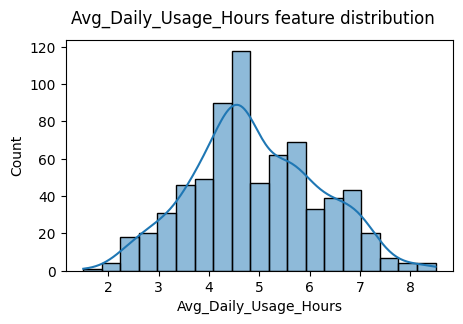

In [3]:
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Avg_Daily_Usage_Hours', 
    kde=True, 
    bins='auto'
)
plt.suptitle("Avg_Daily_Usage_Hours feature distribution")

plt.show()

This plot depicts a histogram highlighting the distribution of the Avg_Daily_Usage_Hours feature.
These results show an approximately symmetric, but slightly skewed distribution.
It also seems like most of the participants use social media for about 4-5 hours and and declines outside this specific range.

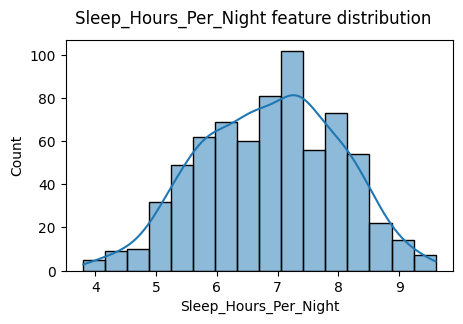

In [4]:
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Sleep_Hours_Per_Night', 
    kde=True, 
    bins='auto'
)
plt.suptitle("Sleep_Hours_Per_Night feature distribution")
plt.show()

Similarly, this plot depicts a histogram highlighting the distribution of the Sleep_Hours_Per_Night feature.
The distribution of the values is close enough to normal distribution, although a little bit skewed to the right.

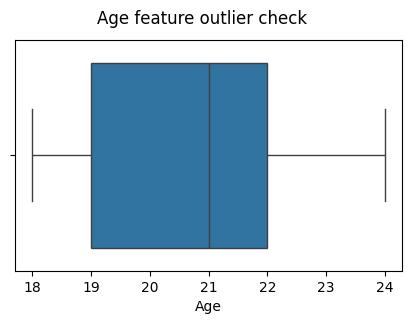

In [5]:
plt.figure(figsize=(5, 3))
sns.boxplot(data=df, x='Age')
plt.suptitle("Age feature outlier check")
plt.show()

The boxplot suggests a relatively symmetric distribution with no evident outliers, though the exact distribution shape cannot be inferred solely from this visualization.

#### Demographic early analysis

This section examines the distribution of observations across countries in order to identify potential imbalances in the dataset.

To ensure sufficient representation, only countries with at least 10 observations were considered minimally sufficient for exploratory analysis, although this threshold remains relatively low for statistical inference. Countries with fewer observations were filtered out to reduce noise and improve readability, reliability and to perform more reliable subsequent comparisons. This threshold was chosen as a minimum sample size constraint to **mitigate the effects of small-sample variability**.

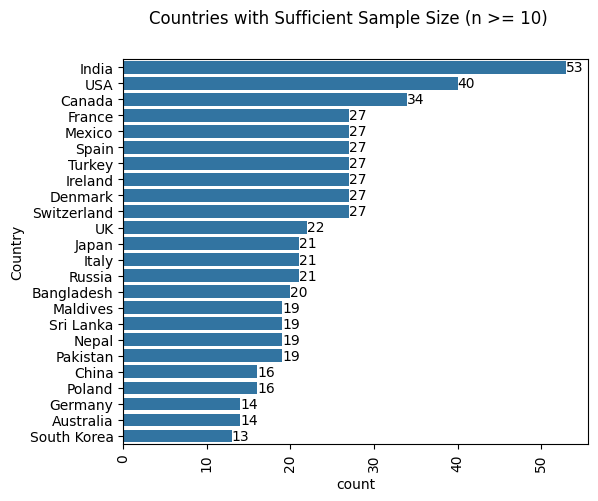

Countries that has ten or more records:  24
Which is only 21.8% of the 110 countries present.


In [6]:
MINIMUM_COUNTRY_OBSERVATION = 10
countries_entries_greater_than_x = df['Country'].value_counts()[df['Country'].value_counts() >= MINIMUM_COUNTRY_OBSERVATION].index #more than 10 records for simplicity
plt.figure(figsize=(6, 5))
ax = sns.countplot(
    data=df, 
    y='Country',
    order=countries_entries_greater_than_x.value_counts().index
)
plt.suptitle("Countries with Sufficient Sample Size (n >= 10)")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()
print('Countries that has ten or more records: ', len(df['Country'].value_counts()[df['Country'].value_counts() > MINIMUM_COUNTRY_OBSERVATION].index))
print(f"Which is only {df['Country'].value_counts()[df['Country'].value_counts() > MINIMUM_COUNTRY_OBSERVATION].count() / df['Country'].nunique() * 100:.1f}% of the 110 countries present.")

Out of the 110 countries present in the dataset, only 24 (21.8%) have at least 10 observations. This indicates a high level of sparsity in the country-level distribution, with most countries **being underrepresented**. This imbalance reinforces the need for applying a minimum sample size threshold, as analyses based on small groups would be more susceptible to noise and unstable estimates.

---

## Bivariate Analysis

This section presents plots **between two features** that (potentially) correlate and can reveal insights not seen before about the dataset.

#### Countries early insights

The ranking is based on countries with **at least 10 observations**. However, differences in sample size may still affect the stability of the estimated averages.
Having restricted the analysis to countries with sufficient sample size, the next step is to examine which countries exhibit the highest average usage within this subset.


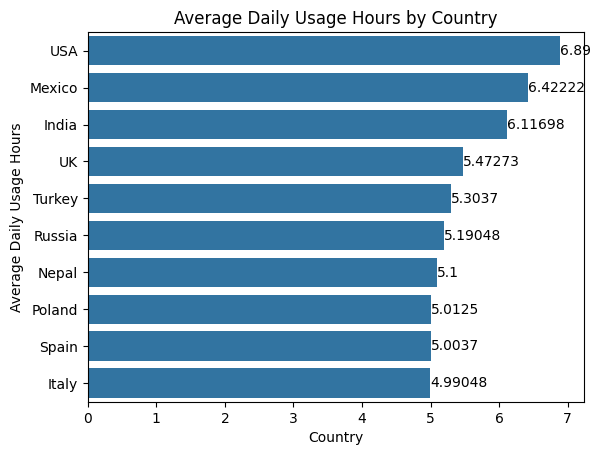

In [7]:
grouped_df = df[df['Country'].isin(countries_entries_greater_than_x)].groupby(by="Country").agg(Avg_usage=('Avg_Daily_Usage_Hours', 'mean')).sort_values(by="Avg_usage", ascending=False).head(10)
ax = sns.barplot(
    data=grouped_df,
    x="Avg_usage",
    y="Country"
)
ax.bar_label(ax.containers[0])

plt.xlabel("Country")

plt.ylabel("Average Daily Usage Hours")
plt.title("Average Daily Usage Hours by Country")

plt.show()

### Correlation table

The correlation table highlights several strong relationships between numerical features to provide more insights and different perspective.

These coefficients can be interpreted as follows:

<div align="center">

| Correlation (r) | Type |
|:-----------------:|------|
| 0.90 to 1.00 | Very strong positive |
| 0.70 to 0.89 | Strong positive |
| 0.40 to 0.69 | Moderate positive |
| 0.10 to 0.39 | Weak positive |
| -0.09 to 0.09 | No correlation |
| -0.10 to -0.39 | Weak negative |
| -0.40 to -0.69 | Moderate negative |
| -0.70 to -0.89 | Strong negative |
| -0.90 to -1.00 | Very strong negative |
</div>

e.g.: As Avg_Daily_Usage_Hours increases, Sleep_Hours_Per_Night strongly decreases (will be shown later on regression plots).

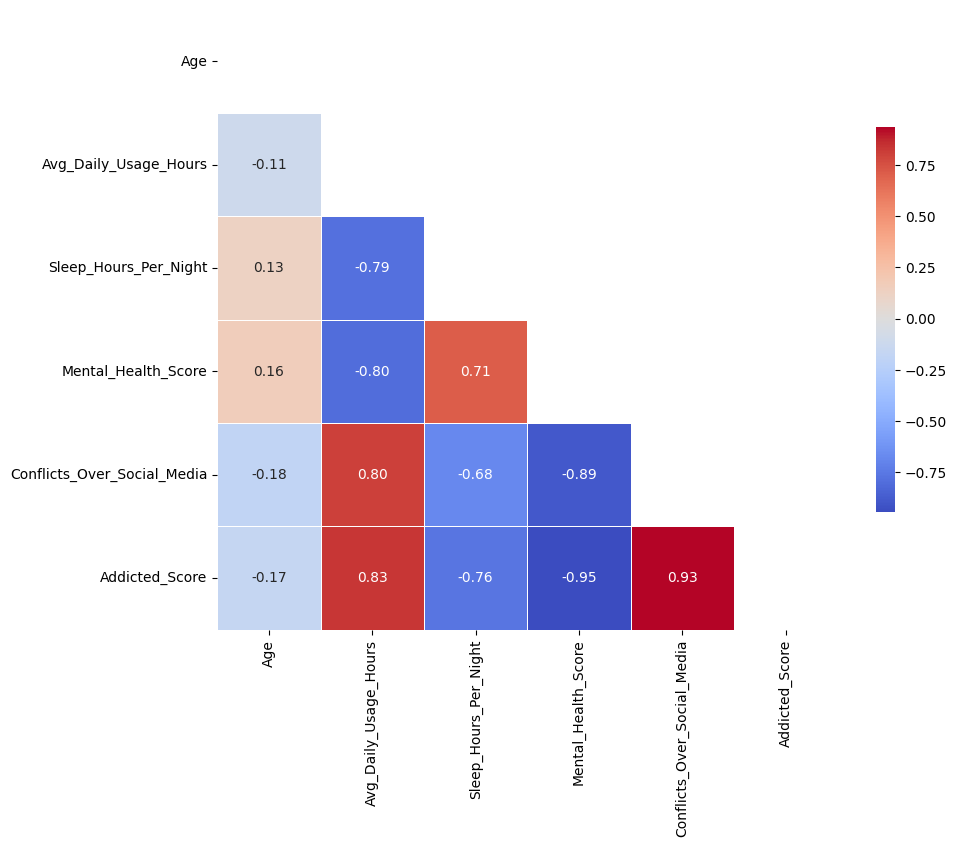

In [8]:
df_numeric = df.select_dtypes(['number'])
df_noIds = df_numeric.drop(columns=['Student_ID'])
corr_matrix = df_noIds.corr()

plt.figure(figsize=(10, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

These correlation coefficients provide some insights about how the features interact with each other. This information will be used heavily throughout this notebook.

### Plotting the regression plots using **Avg_Daily_Usage_Hours** as the primary independent variable

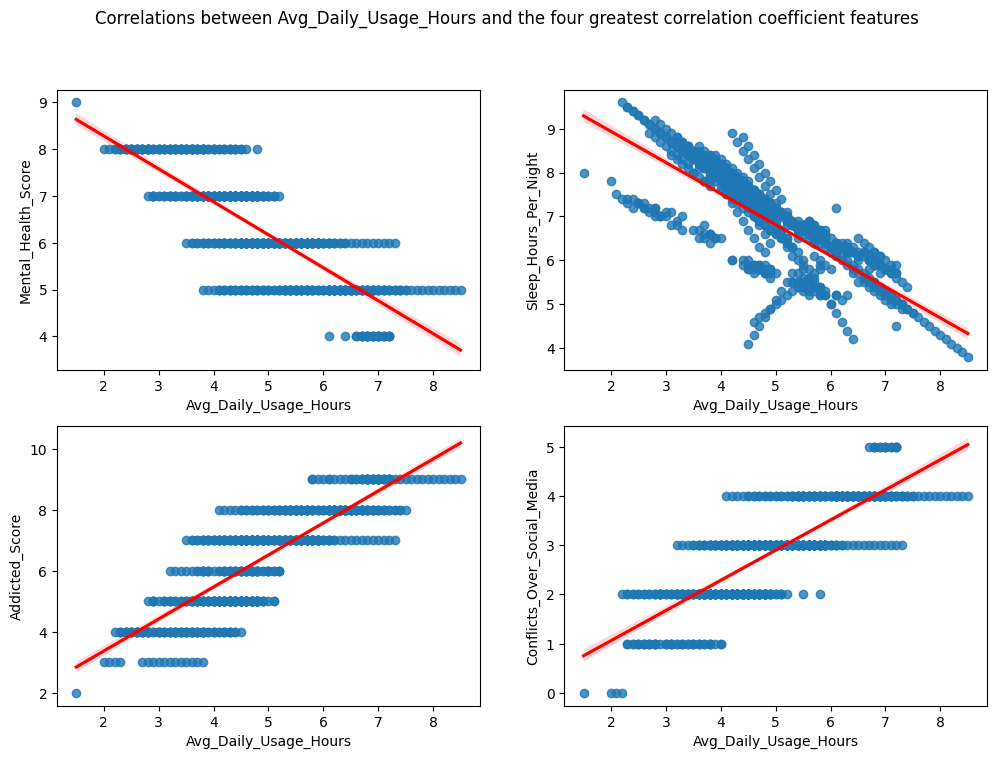

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
ax0 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Mental_Health_Score',
    order=1,
    ax=axes[0][0],
    line_kws=dict(color="r")
)
ax1 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    order=1,
    ax=axes[0][1],
    line_kws=dict(color="r")
)
ax2 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Addicted_Score',
    order=1,
    ax=axes[1][0],
    line_kws=dict(color="r")
)

ax2 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Conflicts_Over_Social_Media',
    order=1,
    ax=axes[1][1],
    line_kws=dict(color="r")
)
plt.suptitle("Correlations between Avg_Daily_Usage_Hours and the four greatest correlation coefficient features")

plt.show()

The four plots have Avg_Daily_Usage_Hours feature in X axis, as this is one of the most influential features in the correlation matrix. It's now possible not only to confirm the correlation's insight, but to build regressions or classification using these variables.

---

### Plotting regression plots using **Addicted_Score** as the primary independent variable

Similarly, based on the same correlation matrix, it's possible to use Addicted_Score as an influential variable as well, as it has four strong correlation relationships.

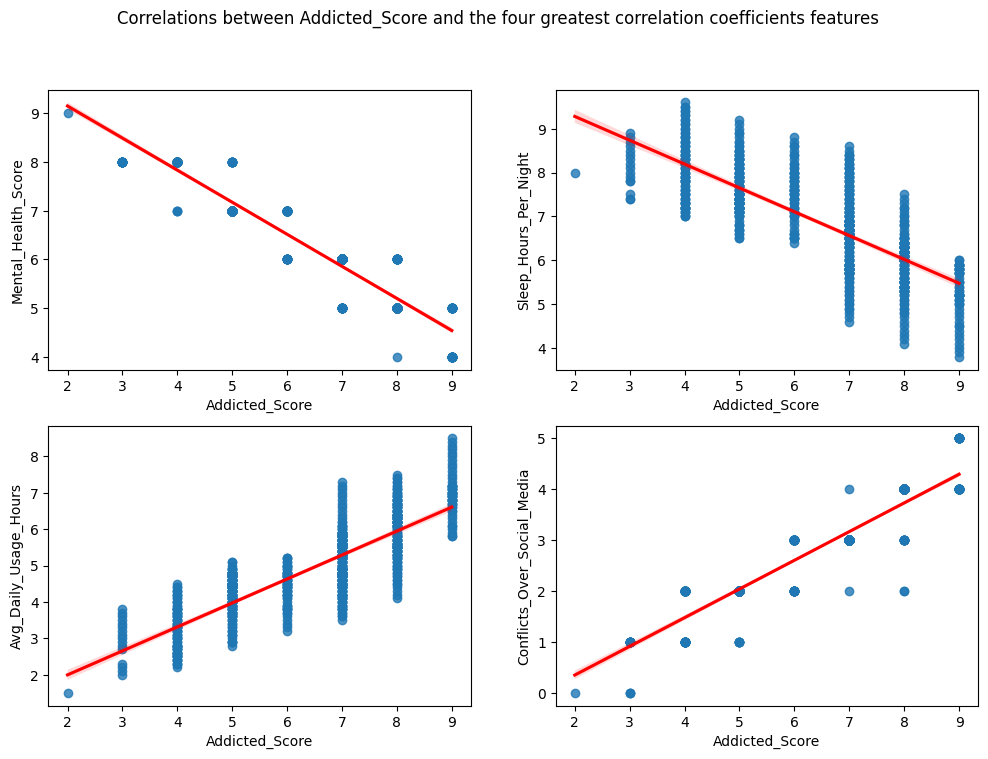

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
ax0 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Mental_Health_Score',
    order=1,
    ax=axes[0][0],
    line_kws=dict(color="r")
)
ax1 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Sleep_Hours_Per_Night',
    order=1,
    ax=axes[0][1],
    line_kws=dict(color="r")
)
ax2 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Avg_Daily_Usage_Hours',
    order=1,
    ax=axes[1][0],
    line_kws=dict(color="r")
)

ax2 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Conflicts_Over_Social_Media',
    order=1,
    ax=axes[1][1],
    line_kws=dict(color="r")
)
plt.suptitle("Correlations between Addicted_Score and the four greatest correlation coefficients features")

plt.show()

Addicted_Score shows strong correlation with several other features:
- Mental_Health_Score
- Sleep_Hours_Per_Night
- Avg_Daily_Usage_Hours
- Conflicts_Over_Social_Media

This can be interpreted as a behavioral association, because usage hours tends to be associated with:
- Decreased mental health score
- Less sleep (quantity/quality)
- More time spent on social media
- More conflicts

### Deeper analysis based on Addicted_Score

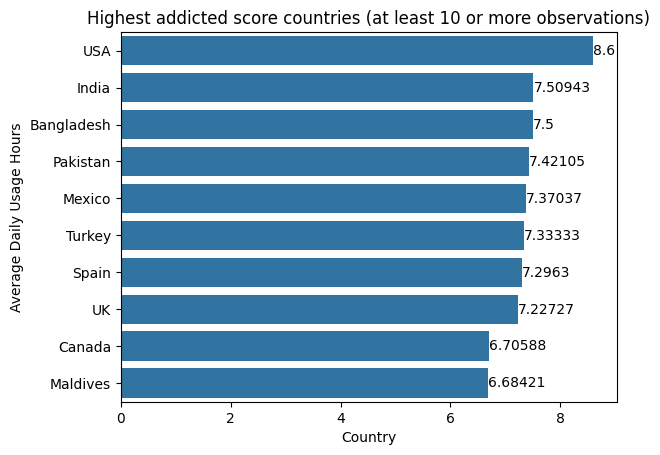

In [11]:
AVG_COUNTRY_ADDICTED_SCORE_GT_10_OBSERVATIONS = df[df['Country'].isin(countries_entries_greater_than_x)].groupby("Country").agg(Avg_Country_Addicted_Score=('Addicted_Score', 'mean'), Avg_Country_Usage_Hours=('Avg_Daily_Usage_Hours', 'mean')).sort_values(by="Avg_Country_Addicted_Score", ascending=False).head(10)
# print(AVG_COUNTRY_ADDICTED_SCORE_GT_10_OBSERVATIONS)
ax = sns.barplot(
    data=AVG_COUNTRY_ADDICTED_SCORE_GT_10_OBSERVATIONS,
    x="Avg_Country_Addicted_Score",
    y="Country",
)
ax.bar_label(ax.containers[0])
plt.xlabel("Country")
plt.ylabel("Average Daily Usage Hours")
plt.title("Highest addicted score countries (at least 10 or more observations)")

plt.show()

### Top 3 addicted score subgroup in-depth analysis

This subdivision can provide insights that only occur in countries with the highest addiction score.

Questions:
- What is the average average daily usage for countries with high addiction status?
- What are their opinions on academic life impact due to social media addiction? Do they feel affected?
- What is the mental health score like in these countries?

Text(0.5, 0.98, 'TOP 3 most addicted countries insights')

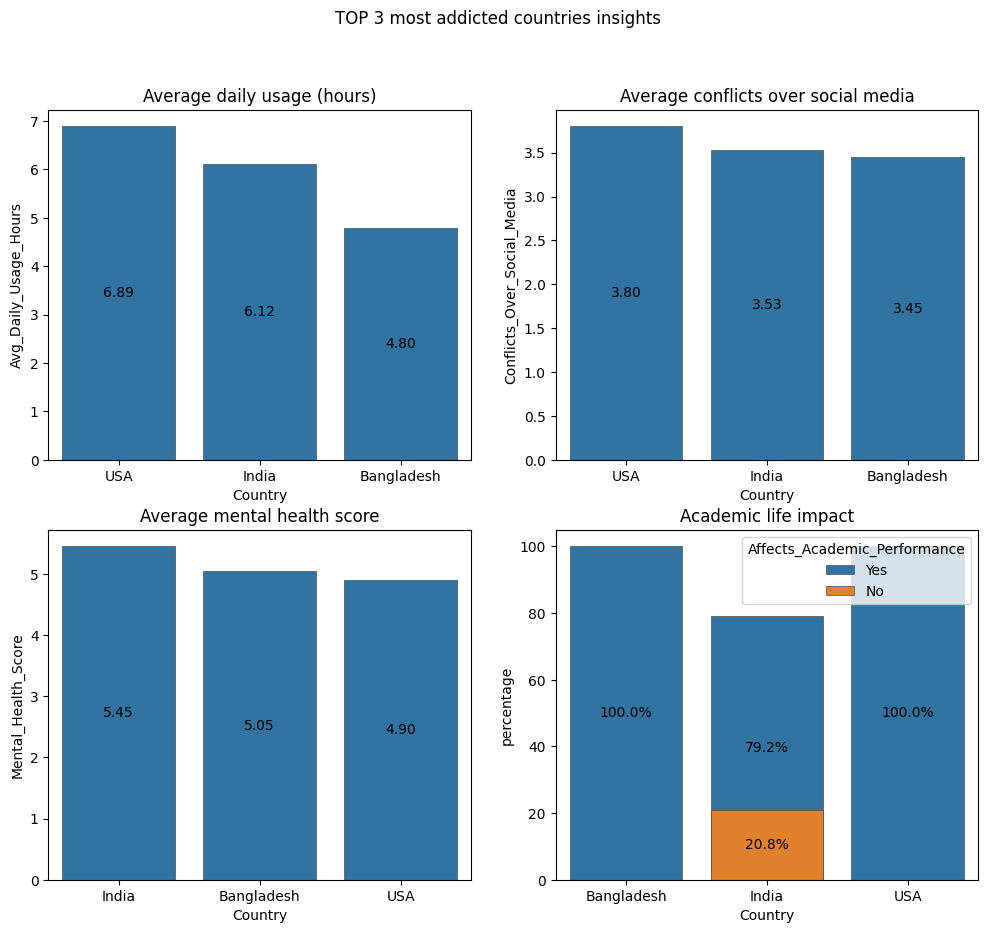

In [12]:
top_3_addicted_score_countries = AVG_COUNTRY_ADDICTED_SCORE_GT_10_OBSERVATIONS.head(3).index
addicted_subgroup_rows = df[df['Country'].isin(top_3_addicted_score_countries)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax0 = sns.barplot(
    addicted_subgroup_rows.groupby("Country").agg({'Avg_Daily_Usage_Hours': 'mean'}).sort_values('Avg_Daily_Usage_Hours', ascending=False),
    y='Avg_Daily_Usage_Hours',
    x="Country",
    edgecolor=".3",
    linewidth=.5,
    ax=axes[0][0]
)
for container in ax0.containers:
    labels = [
        f'{(v.get_height()):.2f}'
        for v in container
    ]
    ax0.bar_label(container, labels=labels, label_type='center')
ax0.set_title("Average daily usage (hours)")

ax1 = sns.barplot(
    addicted_subgroup_rows.groupby("Country").agg({'Conflicts_Over_Social_Media': 'mean'}).sort_values('Conflicts_Over_Social_Media', ascending=False),
    y='Conflicts_Over_Social_Media',
    x="Country",
    edgecolor=".3",
    linewidth=.5,
    ax=axes[0][1]
)
for container in ax1.containers:
    labels = [
        f'{(v.get_height()):.2f}'
        for v in container
    ]
    ax1.bar_label(container, labels=labels, label_type='center')
ax1.set_title("Average conflicts over social media")

ax2 = sns.barplot(
    addicted_subgroup_rows.groupby("Country").agg({'Mental_Health_Score': 'mean'}).sort_values('Mental_Health_Score', ascending=False),
    y='Mental_Health_Score',
    x="Country",
    edgecolor=".3",
    linewidth=.5,
    ax=axes[1][0]
)
for container in ax2.containers:
    labels = [
        f'{(v.get_height()):.2f}'
        for v in container
    ]
    ax2.bar_label(container, labels=labels, label_type='center')
ax2.set_title("Average mental health score")

# print(addicted_subgroup_rows.groupby("Country")['Affects_Academic_Performance'].value_counts(normalize=True).mul(100).round(1).reset_index(name='percentage'))
ax3 = sns.barplot(
    addicted_subgroup_rows.groupby("Country")['Affects_Academic_Performance'].value_counts(normalize=True).mul(100).round(1).reset_index(name='percentage'),
    x="Country",
    y="percentage",
    hue='Affects_Academic_Performance',
    dodge=False,
    edgecolor=".3",
    linewidth=.5,
    ax=axes[1][1]
)
for container in ax3.containers:
    labels = [
        f'{(v.get_height()):.1f}%'
        for v in container
    ]
    ax3.bar_label(container, labels=labels, label_type='center')
ax3.set_title("Academic life impact")

plt.suptitle("TOP 3 most addicted countries insights")

---

## Multivariate Analysis

This section presents plots **between three or more features** that (potentially) correlate and can reveal insights not seen before about the data.

#### Platform usage and Average daily usage

Questions:
- Which social media are the students using the most?
- Is there an equally distributed gender between the platforms?

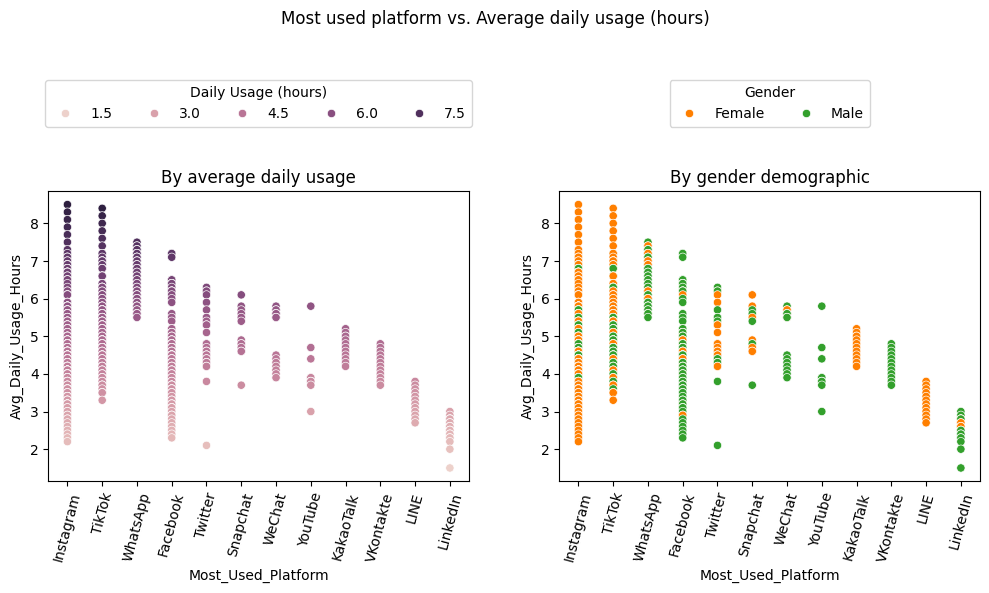

In [13]:
df_sorted = df.sort_values(by="Avg_Daily_Usage_Hours", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10,6))
ax1 = sns.scatterplot(
    data=df_sorted,
    x='Most_Used_Platform',
    y='Avg_Daily_Usage_Hours',
    hue='Avg_Daily_Usage_Hours',
    ax=axes[0]
)
ax1.set_title("By average daily usage")
axes[0].tick_params(axis='x', rotation=75)
sns.move_legend(
    ax1, "lower center",
    bbox_to_anchor=(.5, 1.2), ncol=5,
    title='Daily Usage (hours)', frameon=True
)

ax2 = sns.scatterplot(
    data=df_sorted,
    x='Most_Used_Platform',
    y='Avg_Daily_Usage_Hours',
    hue='Gender',
    palette="Paired_r",
    ax=axes[1]
)
ax2.set_title("By gender demographic")
axes[1].tick_params(axis='x', rotation=75)
sns.move_legend(
    ax2, "lower center",
    bbox_to_anchor=(.5, 1.2), ncol=5,
    title='Gender', frameon=True
)
plt.suptitle("Most used platform vs. Average daily usage (hours)")
plt.tight_layout()
plt.show()

Correlation between **most used platforms vs. the daily usage** shows that Instagram and Tiktok are the most used platforms **in the sample**. It also shows the variety of the time spent by students in these different social media applications.
These plots show the same data under different perspectives, the first shows a distribution of the time spent (in hours), while the latter highlight the gender that uses each platform the most.

#### Sleep hours vs. Daily usage (hours) deeper analysis

This section provides a deeper analysis of the regression plot above (second plot, specifically). The goal is to visualize the same plot under different perspectives. Then subdivide the dataframe to obtain even more information. 

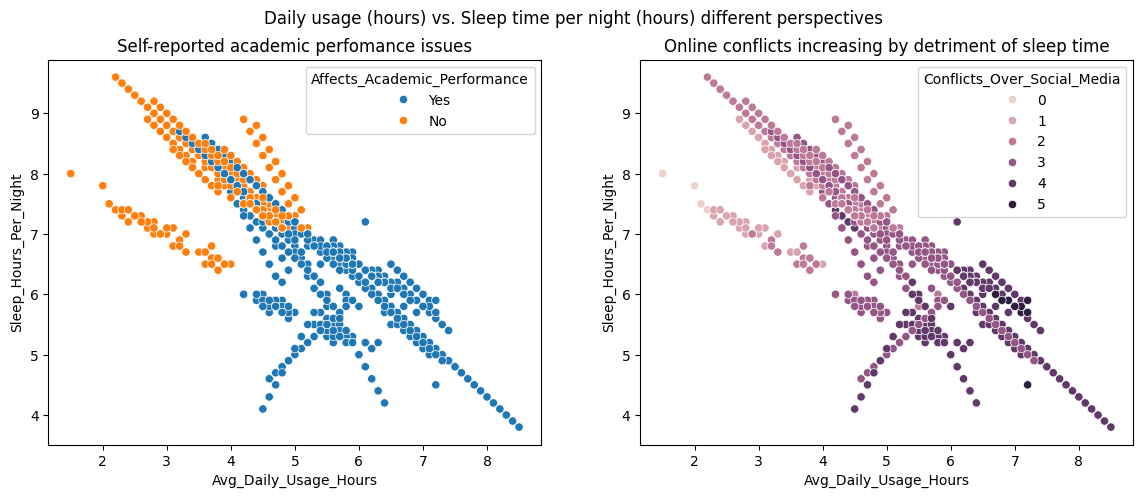

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
ax1 = sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Affects_Academic_Performance',
    ax=axes[0]
)
ax1.set_title("Self-reported academic perfomance issues")

ax2 = sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Conflicts_Over_Social_Media',
    ax=axes[1]
)
ax2.set_title("Online conflicts increasing by detriment of sleep time")
plt.suptitle("Daily usage (hours) vs. Sleep time per night (hours) different perspectives")
plt.show()

#### Subdividing the dataframe

By subdividing the dataframe in two portions, it's possible to dive deeper and highlight insights about the data demographic. In these next two plots, the data is subdivided into: Those who claimed academic performance issues due to the social media addiction, and those who claimed no academic performance issues.

Questions:
- In which academic level students reported affected academic performance the most?
- In which academic level students reported not being affected by social media addiction?

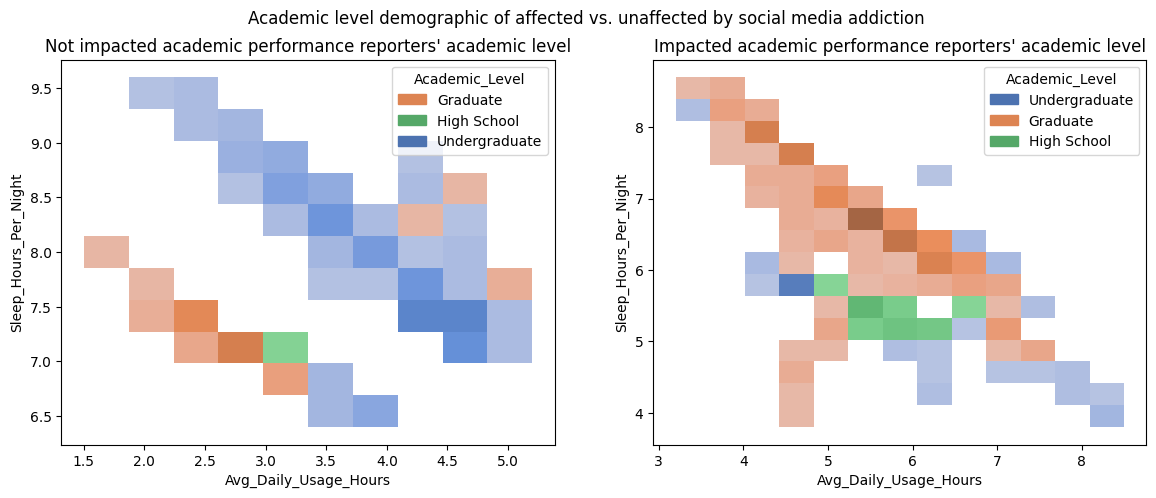

In [15]:
# Dataframe subdivisions
sub_df_self_reported_academic_performance_problems = df[df['Affects_Academic_Performance'] == 'Yes']
sub_df_self_reported_academic_performance_no_problems = df[df['Affects_Academic_Performance'] == 'No']

custom_palette = {
    "High School": "#55a868",
    "Undergraduate": "#4c72b0",
    "Graduate": "#dd8452"
}

fig, axes = plt.subplots(1, 2, figsize=(14,5))

ax0 = sns.histplot(
    data=sub_df_self_reported_academic_performance_no_problems,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Academic_Level',
    ax=axes[0],
    palette=custom_palette
)
ax0.set_title("Not impacted academic performance reporters' academic level")


ax1 = sns.histplot(
    data=sub_df_self_reported_academic_performance_problems,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Academic_Level',
    ax=axes[1],
    palette=custom_palette
)
ax1.set_title("Impacted academic performance reporters' academic level")

plt.suptitle("Academic level demographic of affected vs. unaffected by social media addiction")
plt.show()

The majority of responses show that, Graduate academic level students are the majority who self-reported negative impact in their academic life. While most Undergraduate self-reported no impact.
It's also possible to check the difference in daily usage for both groups.

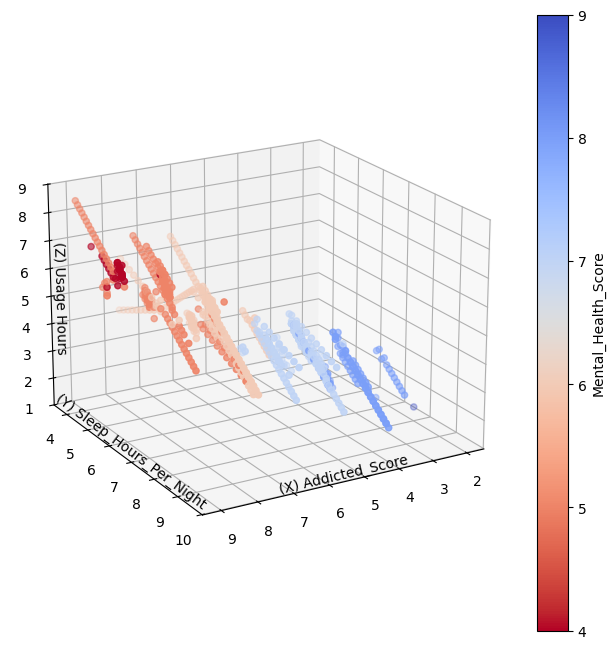

In [16]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    xs=df['Addicted_Score'],
    ys=df['Sleep_Hours_Per_Night'],
    zs=df['Avg_Daily_Usage_Hours'],
    c=df['Mental_Health_Score'],
    cmap=sns.color_palette("coolwarm_r", as_cmap=True)
)

ax.set_xlabel('(X) Addicted_Score', labelpad=-25)
ax.set_ylabel('(Y) Sleep_Hours_Per_Night', labelpad=-25)
ax.set_zlabel('(Z) Usage Hours', labelpad=-25)

fig.colorbar(scatter, ax=ax, label='Mental_Health_Score')
ax.view_init(elev=20, azim=60)

The 3D scatterplot reveals strong, structured relationships between addiction score, sleep duration, and average daily usage, with mental health represented as a color gradient. The X-axis groups observations into distinct bands of addiction scores, indicating a stratified structure that allows comparison across levels of addiction. The color gradient indicates that higher mental health scores are concentrated among individuals with lower addiction, lower usage, and higher sleep, while poorer mental health clusters at higher addiction levels. Notably, a distinct cluster of low mental health scores (highlighted in vibrant red) appears outside the extreme values of sleep and usage, suggesting that poor mental health is not exclusively associated with the most severe behavioral patterns, but may also occur at higher but not extreme levels of usage hours and sleep.

## High-dimensional data simplified with t-SNE

t-SNE is used mainly to plot high-dimensional data into **two- or three-dimensional** space. After the preprocessing phase (which includes normalization and feature selection), the algorithm **tries to preserve how similar points are while mapping them to a lower-dimensional space**. The algorithm also produces a visual grouping **based on feature similarities, which put similar points close together**. It's used to provide relationship insights that would be hard to notice using traditional plotting methods, which are very difficult to interpret as dimensions grow.

This section shows three plots, the first two are essentially the same, but using different libraries (pyplot & plotly), the latter provides us with easier visualization and interactivity. And then a 3D plot using the same library that is easier to interpret as well.

Scaled dataframe:
         Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
0 -1.186915               0.223857              -0.327638   
1  0.958662              -2.243309               0.560423   
2 -0.471723               0.860545              -1.659730   
3 -1.902108              -1.527035               0.116393   
4  0.243470              -0.333245              -0.771668   

   Mental_Health_Score  Conflicts_Over_Social_Media  Addicted_Score  \
0            -0.205520                     0.157063        0.985550   
1             1.605628                    -2.976790       -2.166958   
2            -1.111095                     1.201681        1.616052   
3             0.700054                    -1.932172       -1.536456   
4            -0.205520                    -0.887554        0.355048   

   Gender_Female  Gender_Male  Academic_Level_Graduate  \
0       0.998583    -0.998583                -0.924804   
1      -1.001419     1.001419                 1.081310   
2       0.998

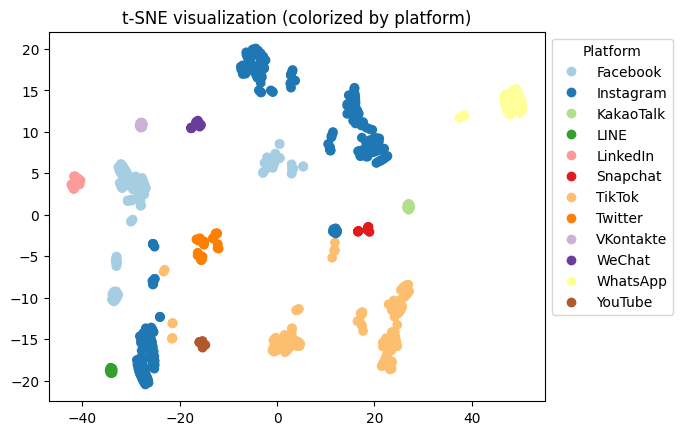

In [17]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


engineered_df = df.drop(columns=['Student_ID', 'Country', 'Relationship_Status'])
usage_cat = engineered_df['Most_Used_Platform'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)

TSNE_optimized_engineered_df = engineered_df
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df)
tsne = TSNE(n_components=2, perplexity=35, learning_rate='auto', max_iter=1500, n_iter_without_progress=300, init='pca')
X_embedded = tsne.fit_transform(X_scaled)
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], cmap='Paired', c=labels)

print("Scaled dataframe:\n", pd.DataFrame(X_scaled, columns=TSNE_optimized_engineered_df.columns).head(5))
X_embedded = tsne.fit_transform(X_scaled)
plt.title("t-SNE visualization (colorized by platform)")

handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    label_names,
    title="Platform",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)
plt.show()


In [18]:
from sklearn.manifold import TSNE
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


engineered_df = df.drop(columns=['Student_ID', 'Country', 'Relationship_Status'])
usage_cat = engineered_df['Most_Used_Platform'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)
TSNE_optimized_engineered_df = engineered_df#.drop(columns=['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'])
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df)

tsne = TSNE(n_components=2, perplexity=35, learning_rate='auto', max_iter=1500, n_iter_without_progress=300, init='pca')
projections = tsne.fit_transform(X_scaled)
fig = px.scatter(
    projections,
    x=0,
    y=1,
    color=engineered_df.Most_Used_Platform,
    labels={'color': 'Most_Used_Platform'},
    hover_data={
            'Avg_Daily_Usage_Hours': engineered_df.Avg_Daily_Usage_Hours,
            'Affects_Academic_Performance': engineered_df.Affects_Academic_Performance,
            'Sleep_Hours_Per_Night': engineered_df.Sleep_Hours_Per_Night,
            'Mental_Health_Score': engineered_df.Mental_Health_Score,
            'Addicted_Score': engineered_df.Addicted_Score
        },
    width=600, 
    height=400,
)
fig.show()


In [19]:
from sklearn.manifold import TSNE
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


engineered_df = df.drop(columns=['Student_ID', 'Country', 'Relationship_Status'])
usage_cat = engineered_df['Most_Used_Platform'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)
TSNE_optimized_engineered_df = engineered_df#.drop(columns=['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'])
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df)

tsne = TSNE(n_components=3, perplexity=40, learning_rate='auto', max_iter=5000, n_iter_without_progress=300, init='pca')
projections = tsne.fit_transform(X_scaled)

fig = px.scatter_3d(
    projections,
    x=0,
    y=1,
    z=2,
    color=df.Most_Used_Platform,
    labels={'color': 'Most_Used_Platform'},
    hover_data={
        'Avg_Daily_Usage_Hours': engineered_df.Avg_Daily_Usage_Hours,
        'Affects_Academic_Performance': engineered_df.Affects_Academic_Performance,
        'Sleep_Hours_Per_Night': engineered_df.Sleep_Hours_Per_Night,
        'Mental_Health_Score': engineered_df.Mental_Health_Score,
        'Addicted_Score': engineered_df.Addicted_Score
    },
    width=800, 
    height=500,
)
fig.show()


## Key insights & Final considerations

### Data pattern observations

- **Avg_Daily_Usage_Hours** is the primary driver feature, alongside **Addicted_Score** reinforcing the pattern.
- **Avg_Daily_Usage_Hours** and **Addicted_Score** is noticeably associated with other features. Within the sample, the data suggests the following trend:

    Students that **spend more hours** and/or have a **higher addiction score** on social media are associated with:

    - Have a lower mental health score
    - Sleep less during the night
    - Have more conflicts over social media

- **Graduate students** report higher perceived impact, while the least impacted are **Undergraduate**.

- The t-SNE dimensionality reduction visualization shows that **some groupings appear to be associated with specific platforms.** Whatsapp for instance, has a very tight cluster that suggests very similar feature values, such as: average usage time, sleep patterns and addiction score. This indicates that users could potentially be subdivided into behavioral profiles for deeper analysis.

- The t-SNE also shows that platform does not appear to be the dominant factor, as it shows three distinct clusters (and two or three smaller ones) for Instagram users, which indicates behavioral differences, which goes from four to nine in addiction score.

### Dataset considerations

Pros:
- **The dataset is clean and requires minimal preprocessing**. The dataset comes in a ready state to be used in data analysis, with no necessary data cleaning techniques beforehand.
- **Correlation patterns are clear and interpretable**. As the regression plot showed, most numerical features (except Age) exhibit strong pairwise correlations over the dataset. This can be potentially used to train Machine Learning models, based on the heaviest driving features, which are: 
    - Avg_Daily_Usage_Hours
    - Addicted_Score

Cons:
- **Country sparsity throughout this notebook is unreliable.** Many countries of this dataset cannot be considered reliable enough, as they have fewer observations, which could lead to wrong subsequent analysis and therefore provide biased and/or inaccurate results.
- **The sample size is insufficient to support statistically robust conclusions or confidently validate hypotheses.** Although the analysis shows that the distributions of some features are considered great (as in not much noise), the limited number of records can present biased or unstable estimates, due to the potentially lower precision while comparing to the whole population.

    What can be done to prevent this problem is:

    - Increase sample size by merging compatible datasets;
    - Data augmentation with synthetic data generation;

### Disclaimers

These findings are based on observed associations and should not be interpreted as causal relationships. Claims like these should be only supported by accredited professionals (which is not the case for this notebook's author).

Any suggestions or errors to report? Send an email to: **contact@andrade.app**.